In [2]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import torch
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / 'diffsim').exists():
    candidate = repo_root.parent
    if (candidate / 'diffsim').exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from diffsim.core.network import Network
from diffsim.core.inference import inference_full_resolution

print('repo_root =', repo_root)

repo_root = /home/tharitt/working/DiffSim


In [3]:
# Paths and settings
RUN_TIMESTAMP = '20260818_102941' # kind of good
MODEL_DIR = Path('/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional') / RUN_TIMESTAMP
RESULTS_DIR = Path('/mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional') / RUN_TIMESTAMP
CONFIG_PATH = MODEL_DIR / 'config.json'

# Optional GT facies directory for quantitative QC (matching file names)
GT_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/facies')

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f'Model run directory not found: {MODEL_DIR}')
if not RESULTS_DIR.is_dir():
    raise FileNotFoundError(f'Results run directory not found: {RESULTS_DIR}')
if not CONFIG_PATH.is_file():
    raise FileNotFoundError(f'Model config not found: {CONFIG_PATH}')

CHECKPOINT_PATH = MODEL_DIR / 'best_model.pth'
if not CHECKPOINT_PATH.exists():
    candidates = sorted(MODEL_DIR.glob('checkpoint_epoch_*.pth'))
    if not candidates:
        raise FileNotFoundError(f'No checkpoint found in {MODEL_DIR}')
    CHECKPOINT_PATH = candidates[-1]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 4
DDIM_STEPS = 100
ETA = 0.3
N_CLASSES = 3

FACIES_NAMES = {
    0: 'Shale',
    1: 'Sand',
    2: 'Silt',
}
FACIES_COLORS = {
    0: '#3E3E3E',
    1: '#E6B422',
    2: '#8FBBD9',
}

cmap6 = mcolors.ListedColormap([FACIES_COLORS[i] for i in range(N_CLASSES)])
norm6 = mcolors.BoundaryNorm(np.arange(-0.5, N_CLASSES + 0.5, 1), cmap6.N)

print('RUN_TIMESTAMP  :', RUN_TIMESTAMP)
print('CONFIG_PATH    :', CONFIG_PATH)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('RESULTS_DIR    :', RESULTS_DIR)
print('DEVICE         :', DEVICE)

RUN_TIMESTAMP  : 20260818_102941
CONFIG_PATH    : /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/config.json
CHECKPOINT_PATH: /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260818_102941/best_model.pth
RESULTS_DIR    : /mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional/20260818_102941
DEVICE         : cuda


In [4]:
def load_model(config_path: Path, checkpoint_path: Path, device: str):
    with open(config_path) as f:
        config = json.load(f)

    cond = config['conditional']
    unet_config = {
        'image_size': config['image_size'],
        'in_channel': cond['in_channel'],
        'out_channel': cond['out_channel'],
        'inner_channel': cond['inner_channel'],
        'channel_mults': cond['channel_mults'],
        'attn_res': cond['attn_res'],
        'res_blocks': cond['res_blocks'],
        'dropout': 0.0,
    }

    network = Network(
        unet=unet_config,
        beta_schedule=cond['beta_schedule'],
        module_name=cond.get('module_name', 'guided_diffusion'),
        predict_type=cond.get('predict_type', 'epsilon'),
    )

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state = ckpt['model_state'] if isinstance(ckpt, dict) and 'model_state' in ckpt else ckpt

    # Checkpoints may contain precomputed schedule buffers not present until set_new_noise_schedule is called.
    incompatible = network.load_state_dict(state, strict=False)
    if incompatible.missing_keys:
        print('Missing keys:', incompatible.missing_keys)
    if incompatible.unexpected_keys:
        print('Unexpected keys (ignored):', incompatible.unexpected_keys)

    network.to(device)
    network.eval()
    return network

network = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
print('Model loaded.')

Unexpected keys (ignored): ['gammas', 'sqrt_recip_gammas', 'sqrt_recipm1_gammas', 'posterior_log_variance_clipped', 'posterior_mean_coef1', 'posterior_mean_coef2']
Model loaded.


Selected ng levels   : [30, 40, 50, 60]
Selected isbx levels : [np.int64(20), np.int64(90), np.int64(160)]


,stem,ng,isbx,seed,z
0,ng30_isbx20_seed8_z019_f128_r3_resamp,30,20,8,19
1,ng30_isbx90_seed8_z003_c12_rand,30,90,8,3
2,ng30_isbx160_seed8_z006_t8_tile,30,160,8,6
3,ng40_isbx20_seed8_z021_t12_tile,40,20,8,21
4,ng40_isbx90_seed8_z006_c11_rand,40,90,8,6
5,ng40_isbx160_seed8_z024_c8_rand,40,160,8,24
6,ng50_isbx20_seed8_z024_c6_rand,50,20,8,24
7,ng50_isbx90_seed8_z022_f256_r0_resamp,50,90,8,22
8,ng50_isbx160_seed8_z018_c14_rand,50,160,8,18
9,ng60_isbx20_seed8_z007_f128_r2_resamp,60,20,8,7


Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]


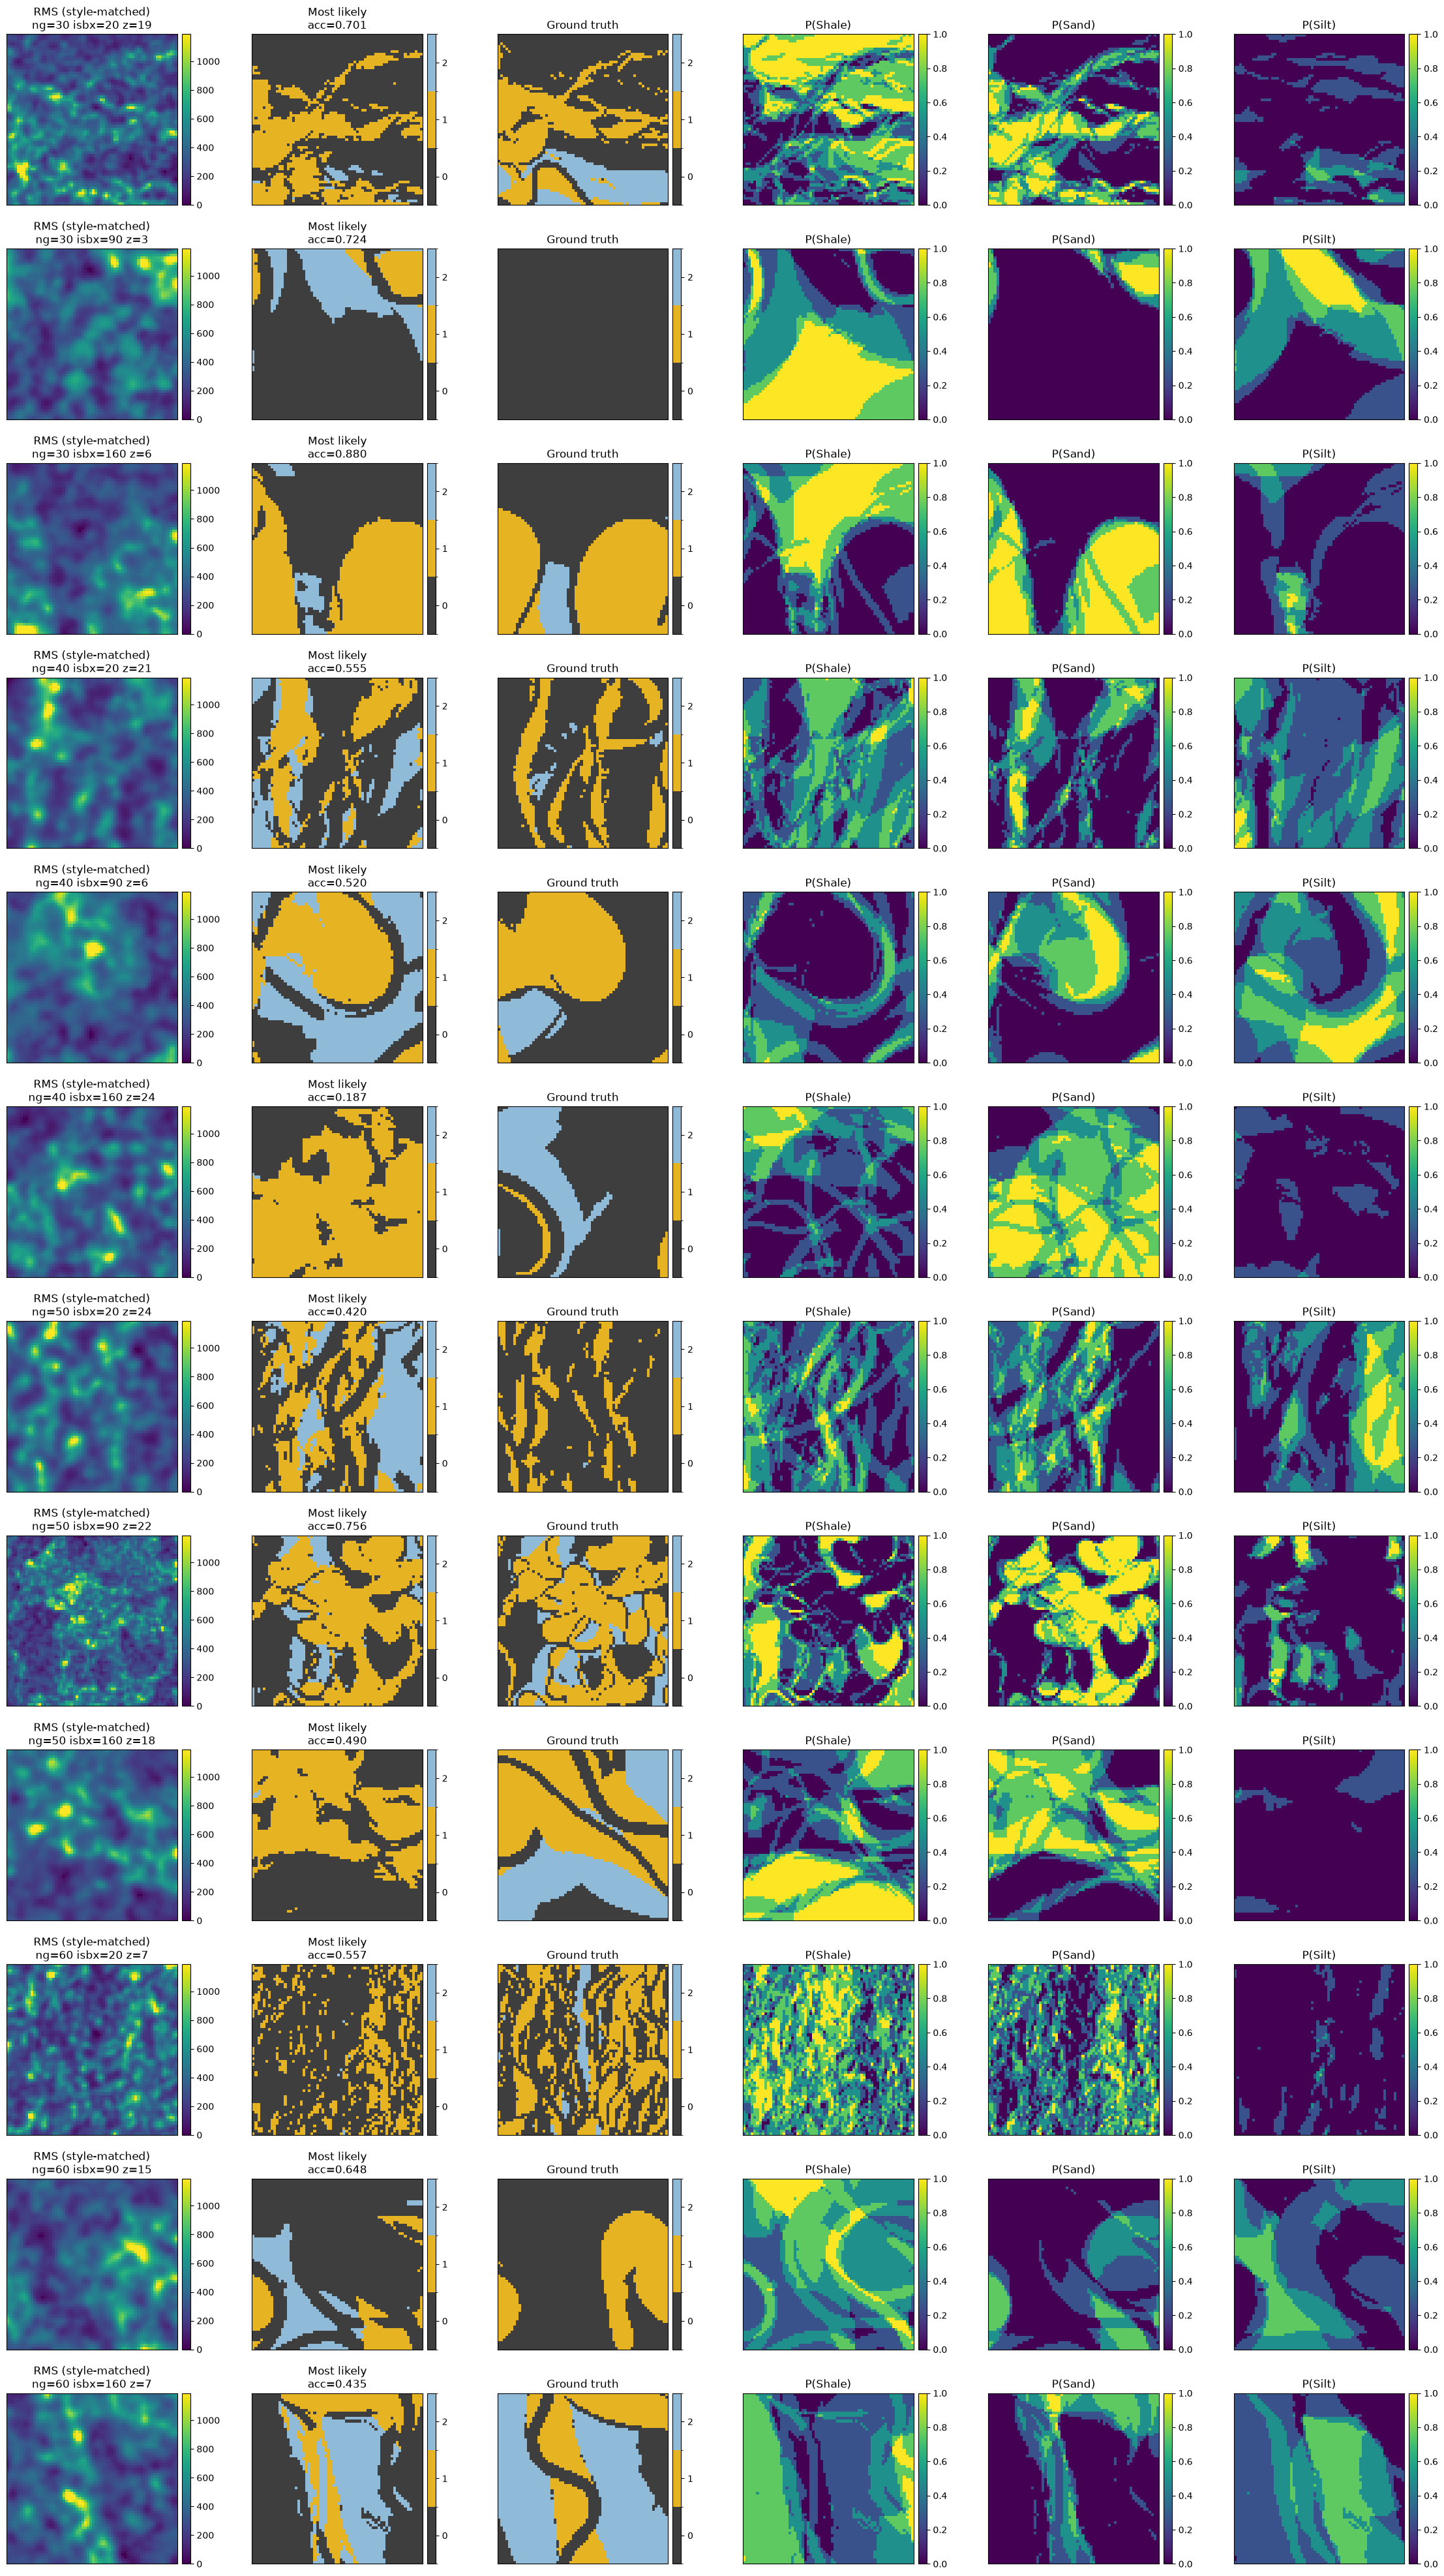

QC metrics for NG×ISBX grid:


,stem,ng,isbx,seed,z,pixel_acc,mean_max_prob,mean_entropy
0,ng30_isbx20_seed8_z019_f128_r3_resamp,30,20,8,19,0.700684,0.785034,0.412590
1,ng30_isbx90_seed8_z003_c12_rand,30,90,8,3,0.724365,0.789124,0.355053
2,ng30_isbx160_seed8_z006_t8_tile,30,160,8,6,0.880371,0.850891,0.296346
3,ng40_isbx20_seed8_z021_t12_tile,40,20,8,21,0.554932,0.635986,0.686475
4,ng40_isbx90_seed8_z006_c11_rand,40,90,8,6,0.519531,0.718811,0.526454
5,ng40_isbx160_seed8_z024_c8_rand,40,160,8,24,0.186523,0.773926,0.447553
6,ng50_isbx20_seed8_z024_c6_rand,50,20,8,24,0.419922,0.663696,0.638174
7,ng50_isbx90_seed8_z022_f256_r0_resamp,50,90,8,22,0.755615,0.824097,0.335906
8,ng50_isbx160_seed8_z018_c14_rand,50,160,8,18,0.490479,0.814758,0.363572
9,ng60_isbx20_seed8_z007_f128_r2_resamp,60,20,8,7,0.557373,0.713928,0.519077


In [5]:
FULL_RMS_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/rms')
FULL_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/facies')


def parse_slice_stem(stem: str):
    # Expected form: ng{ng}_isbx{isbx}_seed{seed}_z{z}_<crop-tag>
    parts = stem.split('_')
    if len(parts) < 4:
        return None
    try:
        return int(parts[0][2:]), int(parts[1][4:]), int(parts[2][4:]), int(parts[3][1:])
    except ValueError:
        return None


# This directory holds ~50K-200K+ files, so avoid regex-matching every filename;
# a single os.scandir pass with cheap string slicing builds the index instead.
catalog = []
for entry in os.scandir(FULL_RMS_DIR):
    if not entry.name.endswith('.npy'):
        continue
    parsed = parse_slice_stem(entry.name[:-4])
    if parsed is None:
        continue
    ng, isbx, seed, z = parsed
    catalog.append({
        'stem': entry.name[:-4],
        'rms_path': Path(entry.path),
        'facies_path': FULL_FACIES_DIR / entry.name,
        'ng': ng,
        'isbx': isbx,
        'seed': seed,
        'z': z,
    })

if not catalog:
    raise RuntimeError(f'No 2D slice files found under {FULL_RMS_DIR}')

cat_df = pd.DataFrame(catalog).sort_values(['ng', 'isbx', 'seed']).reset_index(drop=True)

ng_values = sorted(cat_df['ng'].unique())
isbx_values = sorted(cat_df['isbx'].unique())

if len(ng_values) < 3 or len(isbx_values) < 3:
    raise RuntimeError(
        f'Need at least 3 unique ng and isbx values, got ng={ng_values}, isbx={isbx_values}'
    )

# Pick representative low/mid/high by sorted index
#ng_levels = [ng_values[0], ng_values[len(ng_values)//2], ng_values[-1]]
ng_levels = [ 30, 40, 50, 60]
isbx_levels = [isbx_values[0], isbx_values[len(isbx_values)//2], isbx_values[-1]]

print('Selected ng levels   :', ng_levels)
print('Selected isbx levels :', isbx_levels)

selected_cases = []
for ng in ng_levels:
    for isbx in isbx_levels:
        sub = cat_df[(cat_df['ng'] == ng) & (cat_df['isbx'] == isbx)]
        if len(sub) == 0:
            continue
        # choose median seed for stability
        case = sub.iloc[len(sub)//2].to_dict()
        #case = sub.iloc[0].to_dict()

        selected_cases.append(case)

if len(selected_cases) == 0:
    raise RuntimeError('No (ng, isbx) combinations selected')

selected_df = pd.DataFrame(selected_cases).sort_values(['ng', 'isbx']).reset_index(drop=True)
display(selected_df[['stem', 'ng', 'isbx', 'seed', 'z']])

# Run inference and visualize RMS / prediction / GT
# rms/facies files are already 2D, style-matched crops (see scripts/generate_2d_slices.py),
# so no cube slicing, facies remapping, or histogram matching is needed here.
n_rows = len(selected_df)
n_cols = 3 + N_CLASSES
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 3.3 * n_rows), squeeze=False)

records = []
for i, row in selected_df.iterrows():
    rms_2d = np.load(row['rms_path'])
    gt_2d = np.load(row['facies_path'])
    probs, samples, pred_2d = inference_full_resolution(
        network,
        rms_2d,
        n_samples=4,
        ddim_steps=DDIM_STEPS,
        eta=ETA,
        device=DEVICE,
    )

    prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
    max_prob = prob_stack.max(axis=-1)
    entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

    pixel_acc = float((pred_2d == gt_2d).mean())
    records.append({
        'stem': row['stem'],
        'ng': row['ng'],
        'isbx': row['isbx'],
        'seed': row['seed'],
        'z': row['z'],
        'pixel_acc': pixel_acc,
        'mean_max_prob': float(max_prob.mean()),
        'mean_entropy': float(entropy.mean()),
    })

    ax0, ax1, ax2 = axes[i, 0], axes[i, 1], axes[i, 2]
    im0 = ax0.imshow(rms_2d, origin='lower', cmap='viridis')
    ax0.set_title(f"RMS (style-matched)\nng={row['ng']} isbx={row['isbx']} z={row['z']}")
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)

    im1 = ax1.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax1.set_title(f"Most likely\nacc={pixel_acc:.3f}")
    plt.colorbar(im1, ax=ax1, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    im2 = ax2.imshow(gt_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax2.set_title("Ground truth")
    plt.colorbar(im2, ax=ax2, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    prob_axes = axes[i, 3:3 + N_CLASSES]
    for k, ax in enumerate(prob_axes):
        im_p = ax.imshow(probs[k], origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)
        ax.set_title(f"P({FACIES_NAMES[k]})")
        plt.colorbar(im_p, ax=ax, fraction=0.046, pad=0.02)

    for a in list((ax0, ax1, ax2)) + list(prob_axes):
        a.set_xticks([])
        a.set_yticks([])

plt.tight_layout()
plt.show()

qc_grid_df = pd.DataFrame(records).sort_values(['ng', 'isbx']).reset_index(drop=True)
print('QC metrics for NG×ISBX grid:')
display(qc_grid_df)


Multi-inference:   0%|          | 0/4 [00:00<?, ?it/s]

Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.40it/s]


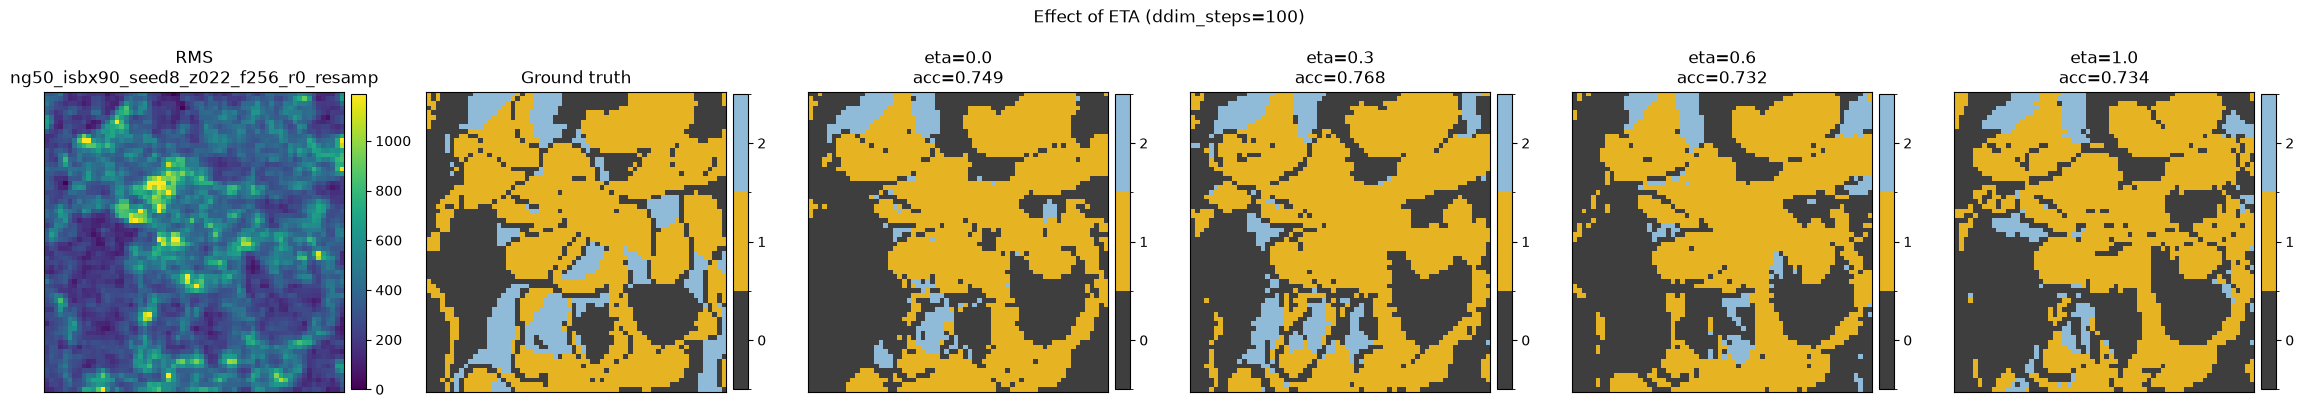

In [6]:
# Effect of ETA (DDIM stochasticity) on inference, fixed DDIM_STEPS
DEMO_STEM = 'ng50_isbx90_seed8_z022_f256_r0_resamp'
demo_rms_2d = np.load(FULL_RMS_DIR / f'{DEMO_STEM}.npy')
demo_gt_2d = np.load(FULL_FACIES_DIR / f'{DEMO_STEM}.npy')

eta_values = [0.0, 0.3, 0.6, 1.0]
n_cols = 2 + len(eta_values)
fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, 3.8), squeeze=True)

im0 = axes[0].imshow(demo_rms_2d, origin='lower', cmap='viridis')
axes[0].set_title(f'RMS\n{DEMO_STEM}')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)

im1 = axes[1].imshow(demo_gt_2d, origin='lower', cmap=cmap6, norm=norm6)
axes[1].set_title('Ground truth')
plt.colorbar(im1, ax=axes[1], ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

for ax, eta in zip(axes[2:], eta_values):
    _, _, pred_2d = inference_full_resolution(
        network,
        demo_rms_2d,
        n_samples=N_SAMPLES,
        ddim_steps=DDIM_STEPS,
        eta=eta,
        device=DEVICE,
    )
    pixel_acc = float((pred_2d == demo_gt_2d).mean())
    im = ax.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax.set_title(f'eta={eta}\nacc={pixel_acc:.3f}')
    plt.colorbar(im, ax=ax, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

for a in axes:
    a.set_xticks([])
    a.set_yticks([])

fig.suptitle(f'Effect of ETA (ddim_steps={DDIM_STEPS})', y=1.05)
plt.tight_layout()
plt.show()

Multi-inference: 100%|██████████| 4/4 [00:06<00:00,  1.56s/it]


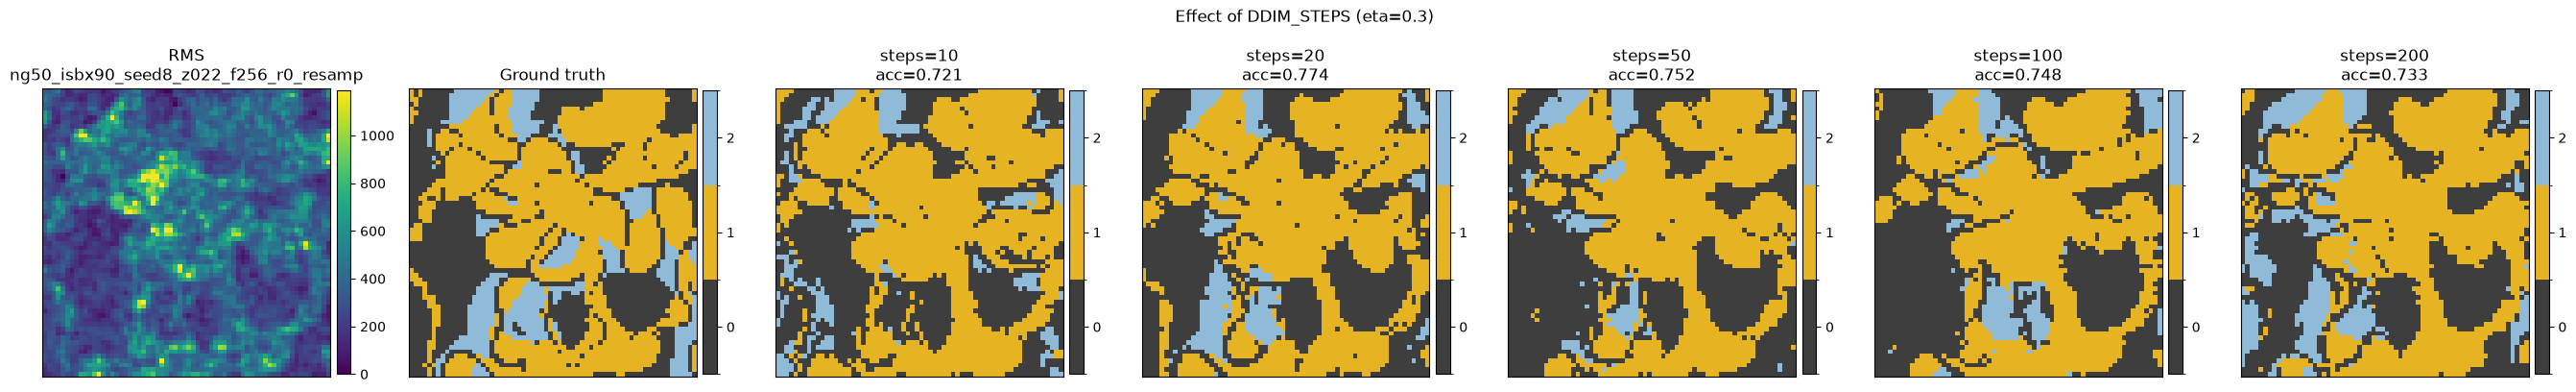

In [7]:
# Effect of DDIM_STEPS (number of denoising steps) on inference, fixed ETA
ddim_steps_values = [10, 20, 50, 100, 200]
n_cols = 2 + len(ddim_steps_values)
fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, 3.8), squeeze=True)

im0 = axes[0].imshow(demo_rms_2d, origin='lower', cmap='viridis')
axes[0].set_title(f'RMS\n{DEMO_STEM}')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)

im1 = axes[1].imshow(demo_gt_2d, origin='lower', cmap=cmap6, norm=norm6)
axes[1].set_title('Ground truth')
plt.colorbar(im1, ax=axes[1], ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

for ax, steps in zip(axes[2:], ddim_steps_values):
    _, _, pred_2d = inference_full_resolution(
        network,
        demo_rms_2d,
        n_samples=N_SAMPLES,
        ddim_steps=steps,
        eta=ETA,
        device=DEVICE,
    )
    pixel_acc = float((pred_2d == demo_gt_2d).mean())
    im = ax.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax.set_title(f'steps={steps}\nacc={pixel_acc:.3f}')
    plt.colorbar(im, ax=ax, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

for a in axes:
    a.set_xticks([])
    a.set_yticks([])

fig.suptitle(f'Effect of DDIM_STEPS (eta={ETA})', y=1.05)
plt.tight_layout()
plt.show()

,stem,ng,isbx,seed,z
0,ng30_isbx20_seed8_z006_f256_r3_resamp,30,20,8,6
1,ng30_isbx90_seed8_z012_c14_rand,30,90,8,12
2,ng30_isbx160_seed8_z015_f256_r3_resamp,30,160,8,15
3,ng40_isbx20_seed8_z021_c13_rand,40,20,8,21
4,ng40_isbx90_seed8_z010_t14_tile,40,90,8,10
5,ng40_isbx160_seed8_z018_c11_rand,40,160,8,18
6,ng50_isbx20_seed8_z016_t10_tile,50,20,8,16
7,ng50_isbx90_seed8_z022_f256_r1_resamp,50,90,8,22
8,ng50_isbx160_seed8_z001_t3_tile,50,160,8,1
9,ng60_isbx20_seed8_z018_c4_rand,60,20,8,18


rms_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/rms/ng30_isbx20_seed8_z006_f256_r3_resamp.npy, facies_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/facies/ng30_isbx20_seed8_z006_f256_r3_resamp.npy


Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.34it/s]


rms_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/rms/ng30_isbx90_seed8_z012_c14_rand.npy, facies_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/facies/ng30_isbx90_seed8_z012_c14_rand.npy


Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.37it/s]


...

Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.38it/s]


rms_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/rms/ng60_isbx90_seed8_z028_c3_rand.npy, facies_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/facies/ng60_isbx90_seed8_z028_c3_rand.npy


Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.39it/s]


rms_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/rms/ng60_isbx160_seed8_z015_t6_tile.npy, facies_path: /mnt/sda_data/tharitt/diffsim/data/slice_data_2d/test/facies/ng60_isbx160_seed8_z015_t6_tile.npy


Multi-inference: 100%|██████████| 4/4 [00:02<00:00,  1.40it/s]


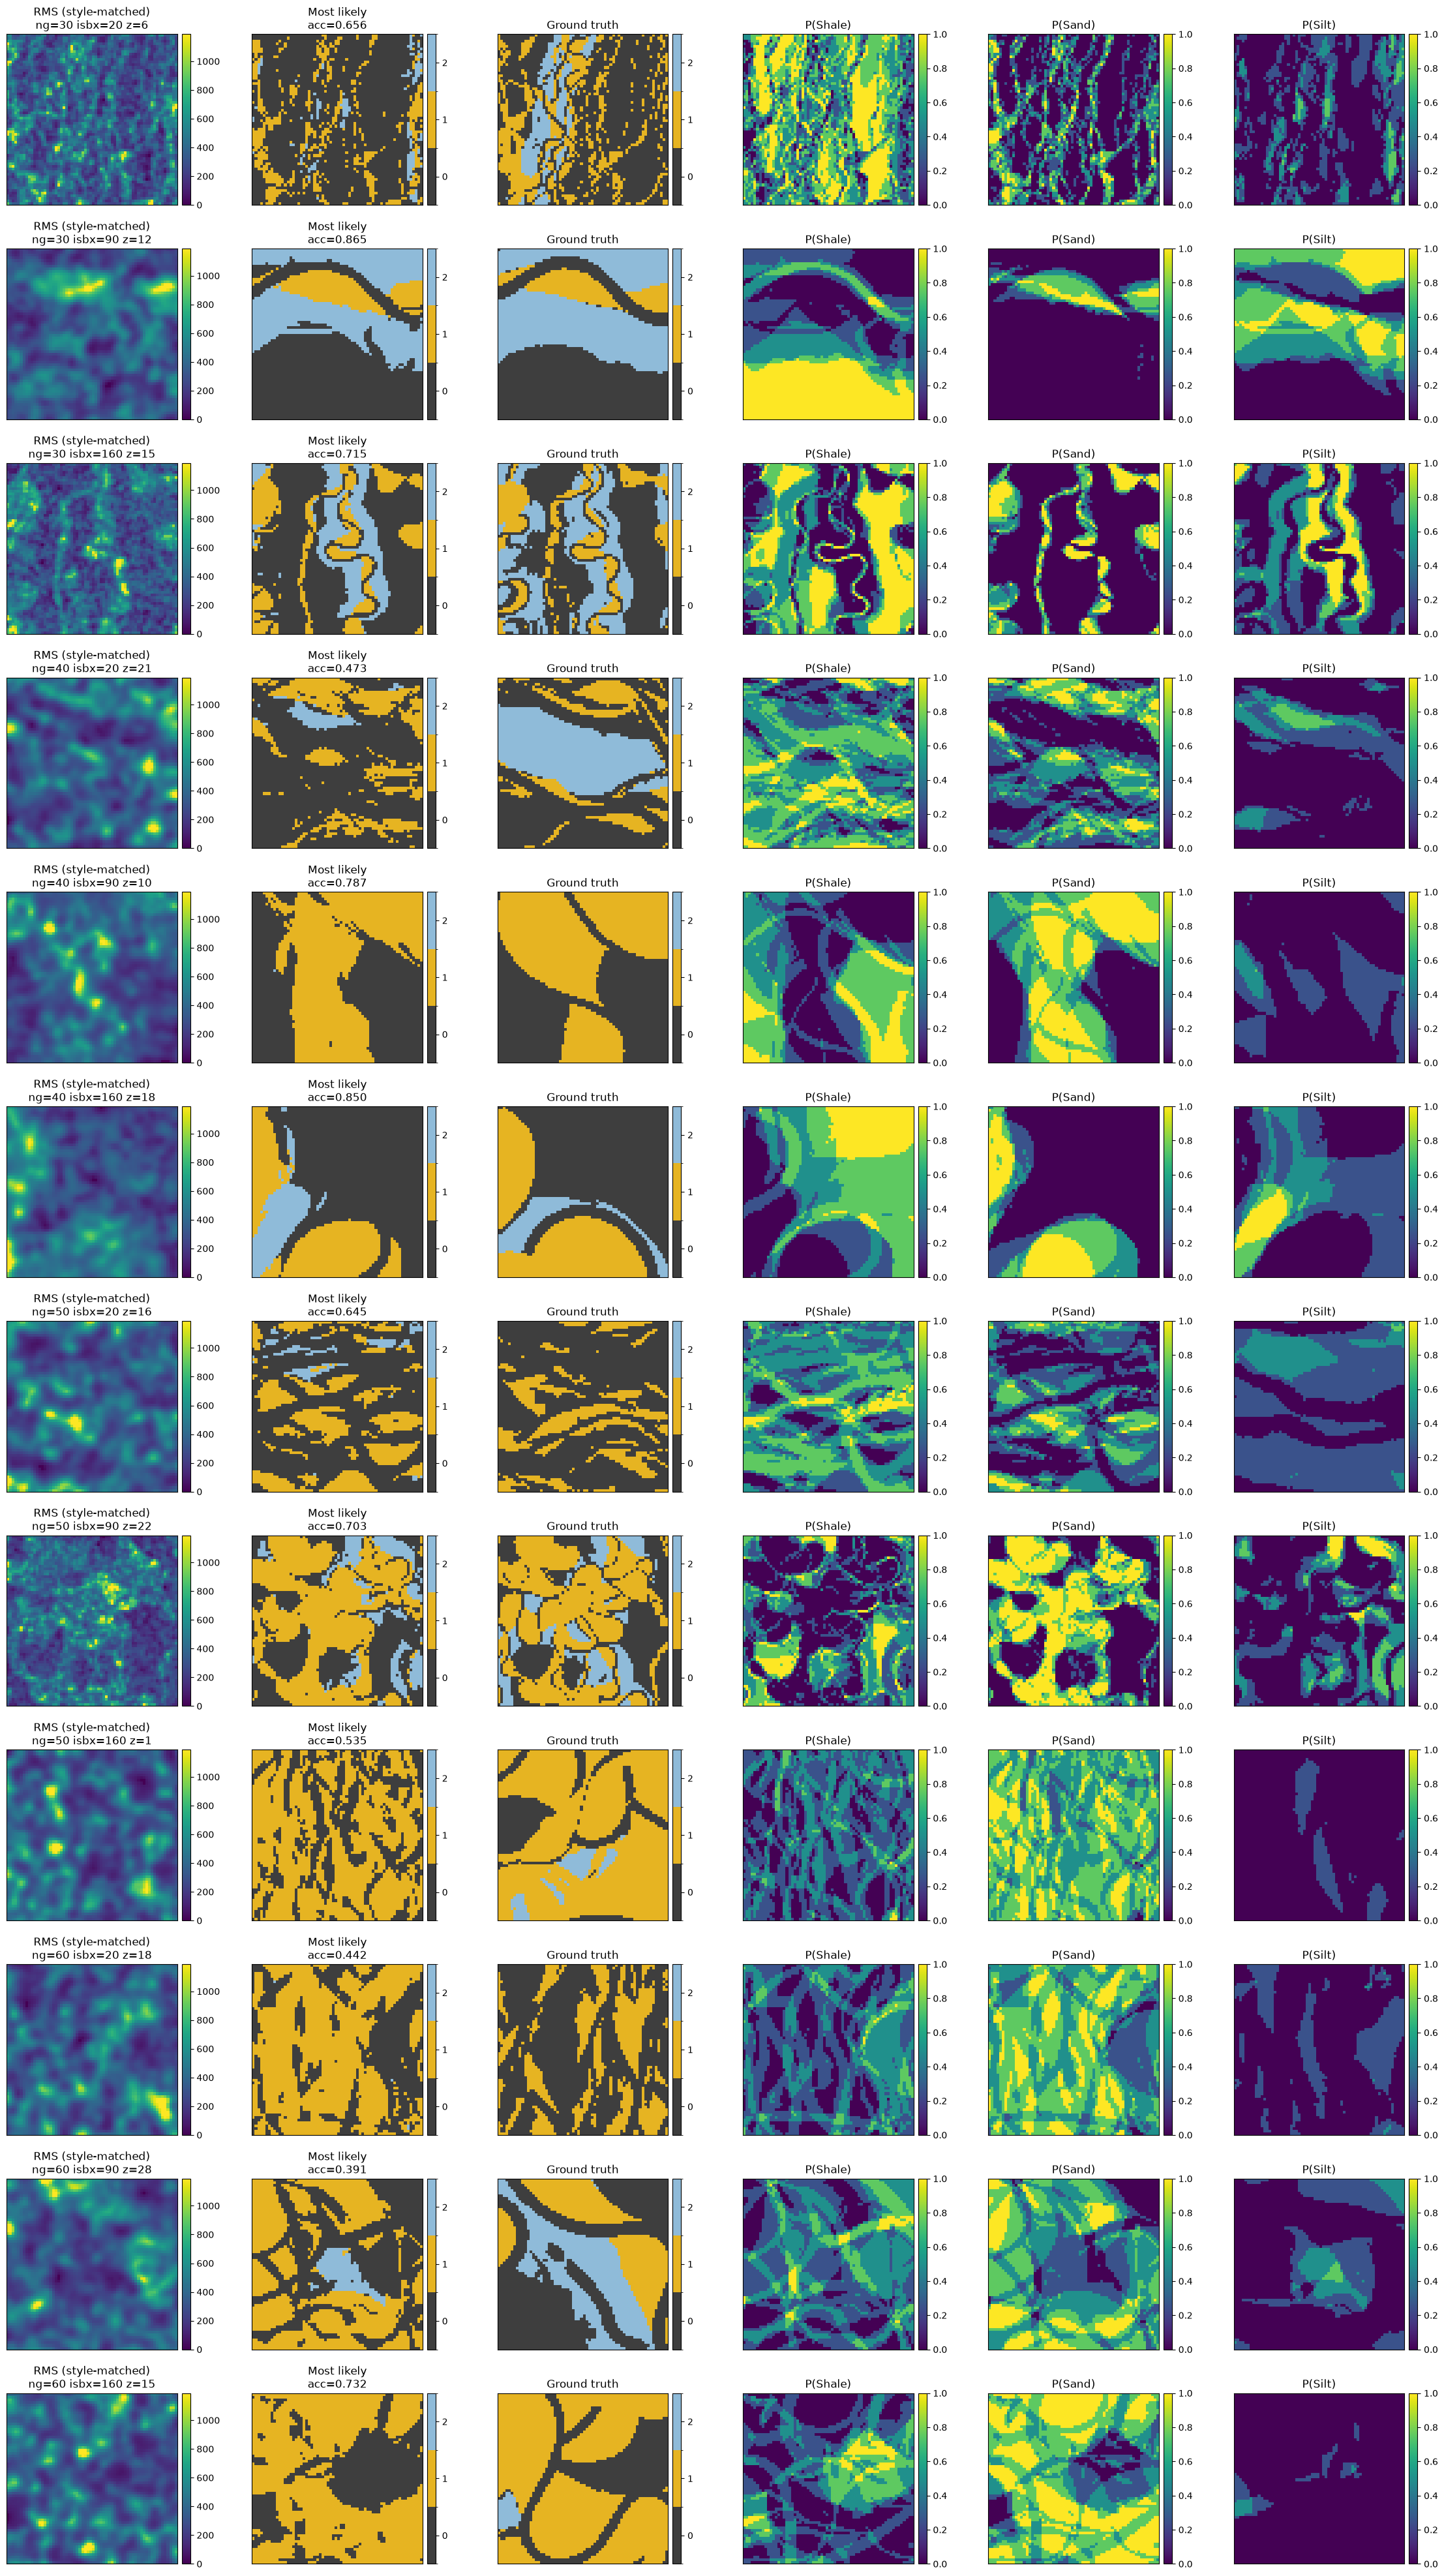

QC metrics (with per-class probability maps):


,stem,ng,isbx,seed,z,pixel_acc,mean_max_prob,mean_entropy
0,ng30_isbx20_seed8_z006_f256_r3_resamp,30,20,8,6,0.655762,0.742188,0.485236
1,ng30_isbx90_seed8_z012_c14_rand,30,90,8,12,0.865234,0.818665,0.335788
2,ng30_isbx160_seed8_z015_f256_r3_resamp,30,160,8,15,0.715088,0.811157,0.341094
3,ng40_isbx20_seed8_z021_c13_rand,40,20,8,21,0.472900,0.706360,0.539430
4,ng40_isbx90_seed8_z010_t14_tile,40,90,8,10,0.787109,0.805725,0.376176
5,ng40_isbx160_seed8_z018_c11_rand,40,160,8,18,0.850098,0.779358,0.426882
6,ng50_isbx20_seed8_z016_t10_tile,50,20,8,16,0.645264,0.633301,0.721517
7,ng50_isbx90_seed8_z022_f256_r1_resamp,50,90,8,22,0.703369,0.789368,0.393381
8,ng50_isbx160_seed8_z001_t3_tile,50,160,8,1,0.534912,0.709412,0.527213
9,ng60_isbx20_seed8_z018_c4_rand,60,20,8,18,0.441650,0.693359,0.581372


In [8]:
# Inference + per-class probability maps for a fixed seed=8 NG x ISBX grid
PROB_STEMS = [
    'ng30_isbx20_seed8', 'ng30_isbx90_seed8', 'ng30_isbx160_seed8',
    'ng40_isbx20_seed8', 'ng40_isbx90_seed8', 'ng40_isbx160_seed8',
    'ng50_isbx20_seed8', 'ng50_isbx90_seed8', 'ng50_isbx160_seed8',
    'ng60_isbx20_seed8', 'ng60_isbx90_seed8', 'ng60_isbx160_seed8',
]


def parse_ng_isbx_seed(stem: str):
    parts = stem.split('_')
    return int(parts[0][2:]), int(parts[1][4:]), int(parts[2][4:])


prob_cases = []
for stem in PROB_STEMS:
    ng, isbx, seed = parse_ng_isbx_seed(stem)
    sub = cat_df[(cat_df['ng'] == ng) & (cat_df['isbx'] == isbx) & (cat_df['seed'] == seed)]
    if len(sub) == 0:
        print(f'No match for {stem} (ng={ng}, isbx={isbx}, seed={seed})')
        continue
    # multiple z/crop variants can share the same (ng, isbx, seed); take the first
    prob_cases.append(sub.iloc[0].to_dict())

if not prob_cases:
    raise RuntimeError('No matching cases found for PROB_STEMS')

prob_df = pd.DataFrame(prob_cases).reset_index(drop=True)
display(prob_df[['stem', 'ng', 'isbx', 'seed', 'z']])

n_rows = len(prob_df)
n_cols = 3 + N_CLASSES
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 3.3 * n_rows), squeeze=False)

prob_records = []
for i, row in prob_df.iterrows():
    print(f"rms_path: {row['rms_path']}, facies_path: {row['facies_path']}")
    rms_2d = np.load(row['rms_path'])
    gt_2d = np.load(row['facies_path'])

    probs, samples, pred_2d = inference_full_resolution(
        network,
        rms_2d,
        n_samples=N_SAMPLES,
        ddim_steps=DDIM_STEPS,
        eta=ETA,
        device=DEVICE,
    )

    prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
    max_prob = prob_stack.max(axis=-1)
    entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

    pixel_acc = float((pred_2d == gt_2d).mean())
    prob_records.append({
        'stem': row['stem'],
        'ng': row['ng'],
        'isbx': row['isbx'],
        'seed': row['seed'],
        'z': row['z'],
        'pixel_acc': pixel_acc,
        'mean_max_prob': float(max_prob.mean()),
        'mean_entropy': float(entropy.mean()),
    })

    ax0, ax1, ax2 = axes[i, 0], axes[i, 1], axes[i, 2]
    im0 = ax0.imshow(rms_2d, origin='lower', cmap='viridis')
    ax0.set_title(f"RMS (style-matched)\nng={row['ng']} isbx={row['isbx']} z={row['z']}")
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)

    im1 = ax1.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax1.set_title(f"Most likely\nacc={pixel_acc:.3f}")
    plt.colorbar(im1, ax=ax1, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    im2 = ax2.imshow(gt_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax2.set_title("Ground truth")
    plt.colorbar(im2, ax=ax2, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    prob_axes = axes[i, 3:3 + N_CLASSES]
    for k, ax in enumerate(prob_axes):
        im_p = ax.imshow(probs[k], origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)
        ax.set_title(f"P({FACIES_NAMES[k]})")
        plt.colorbar(im_p, ax=ax, fraction=0.046, pad=0.02)

    for a in list((ax0, ax1, ax2)) + list(prob_axes):
        a.set_xticks([])
        a.set_yticks([])

plt.tight_layout()
plt.show()

prob_grid_df = pd.DataFrame(prob_records)
print('QC metrics (with per-class probability maps):')
display(prob_grid_df)